In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create folder for saving charts
os.makedirs("charts", exist_ok=True)

# Style settings
sns.set(style="whitegrid")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [58]:
# load titanic dataset from seaborn
df = sns.load_dataset('titanic')

# display first five rows
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [59]:
# dataset information
print("Shape of Dataset:", df.shape)

print("\nColumns:\n", df.columns)

print("\nMissing Values:\n")

print(df.isnull().sum())

Shape of Dataset: (891, 15)

Columns:
 Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

Missing Values:

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [60]:
# data cleaning
# Fill missing age values with median
df['age'] = df['age'].fillna(df['age'].median())

# Fill embarked missing values with mode
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Drop deck column due to excessive missing values
df.drop(columns=['deck'], inplace=True)

print("Missing values handled successfully")

Missing values handled successfully


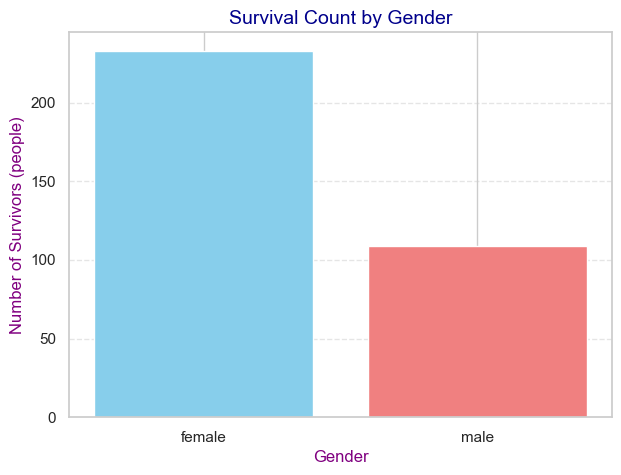

Insight: Female passengers had a significantly higher survival count than male passengers.


In [61]:
# Bar Chart

survival_gender = df.groupby('sex')['survived'].sum()

plt.figure(figsize=(7,5))

plt.bar(
    survival_gender.index,
    survival_gender.values,
    color=['skyblue', 'lightcoral']
)

plt.title(
    "Survival Count by Gender",
    fontsize=14,
    color='darkblue'
)

plt.xlabel(
    "Gender",
    fontsize=12,
    color='purple'
)

plt.ylabel(
    "Number of Survivors (people)",
    fontsize=12,
    color='purple'
)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.savefig('charts/barchart.png')

plt.show()

print("Insight: Female passengers had a significantly higher survival count than male passengers.")

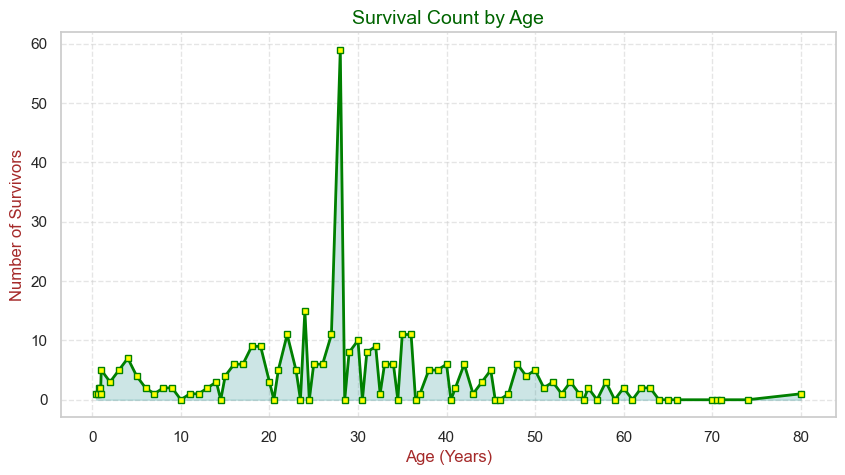

Insight: Younger and middle-aged passengers showed higher survival counts compared to older passengers.


In [62]:
age_survival = df.groupby('age')['survived'].sum()

plt.figure(figsize=(10,5))

plt.plot(
    age_survival.index,
    age_survival.values,
    color='green',
    linewidth=2,
    marker='s',
    markersize=5,
    markerfacecolor='yellow'
)

# Fill area under line
plt.fill_between(
    age_survival.index,
    age_survival.values,
    color='teal',
    alpha=0.2
)

plt.title(
    "Survival Count by Age",
    fontsize=14,
    color='darkgreen'
)

plt.xlabel(
    "Age (Years)",
    fontsize=12,
    color='brown'
)

plt.ylabel(
    "Number of Survivors",
    fontsize=12,
    color='brown'
)

plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig('charts/line_age_survival.png')

plt.show()

print("Insight: Younger and middle-aged passengers showed higher survival counts compared to older passengers.")

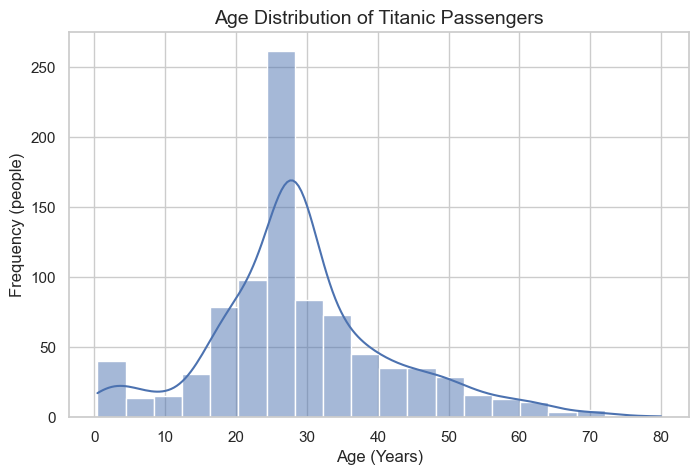

Insight: Most passengers aboard the Titanic were between 20 and 40 years old.


<Figure size 640x480 with 0 Axes>

In [63]:
# histogram
plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=20, kde=True)

plt.title("Age Distribution of Titanic Passengers", fontsize=14)

plt.xlabel("Age (Years)")

plt.ylabel("Frequency (people)")

plt.show()

plt.savefig('charts/histogram.png')

print("Insight: Most passengers aboard the Titanic were between 20 and 40 years old.")

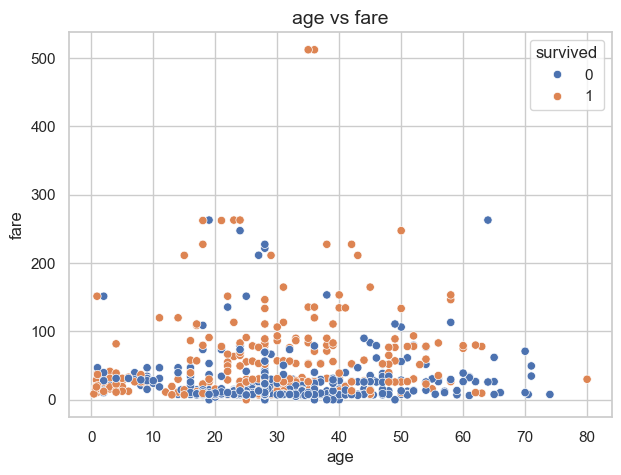

Insight: This scatter plot shows the relationship between age and fare with survival distribution.



<Figure size 640x480 with 0 Axes>

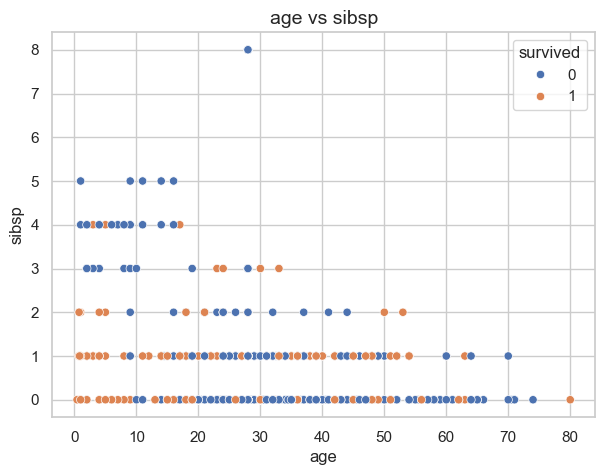

Insight: This scatter plot shows the relationship between age and sibsp with survival distribution.



<Figure size 640x480 with 0 Axes>

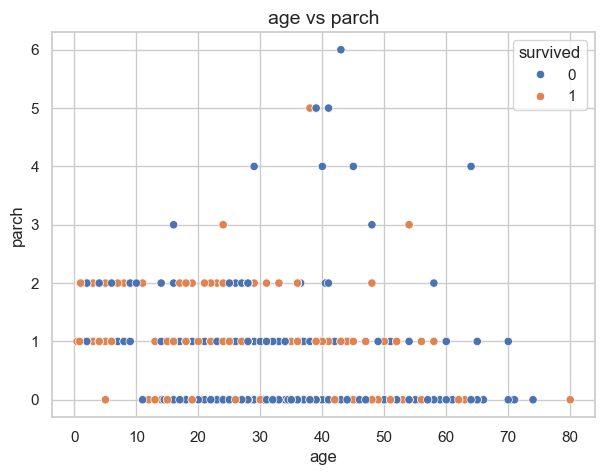

Insight: This scatter plot shows the relationship between age and parch with survival distribution.



<Figure size 640x480 with 0 Axes>

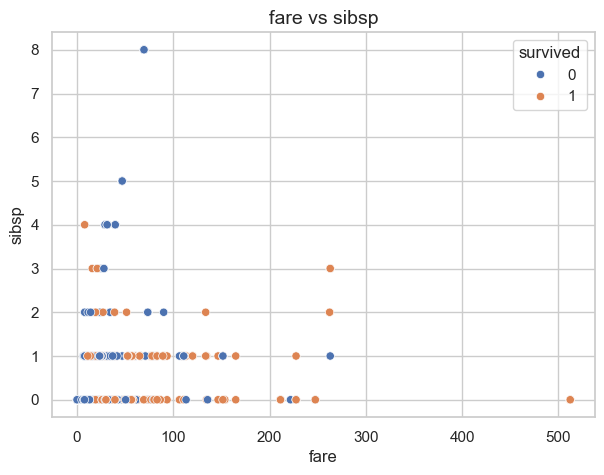

Insight: This scatter plot shows the relationship between fare and sibsp with survival distribution.



<Figure size 640x480 with 0 Axes>

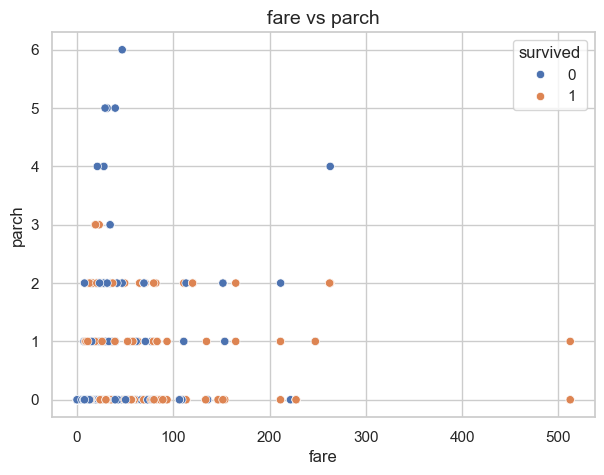

Insight: This scatter plot shows the relationship between fare and parch with survival distribution.



<Figure size 640x480 with 0 Axes>

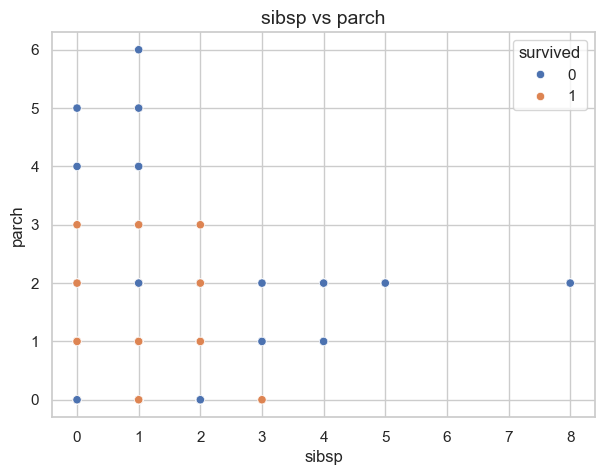

Insight: This scatter plot shows the relationship between sibsp and parch with survival distribution.



<Figure size 640x480 with 0 Axes>

In [64]:
numeric_cols = ['age', 'fare', 'sibsp', 'parch']

for i in range(len(numeric_cols)):
    
    for j in range(i + 1, len(numeric_cols)):
        
        plt.figure(figsize=(7,5))
        
        sns.scatterplot(
            data=df,
            x=numeric_cols[i],
            y=numeric_cols[j],
            hue='survived'
        )
        
        plt.title(f"{numeric_cols[i]} vs {numeric_cols[j]}", fontsize=14)
        
        plt.xlabel(numeric_cols[i])
        plt.ylabel(numeric_cols[j])
        
        plt.show()

        plt.savefig(f'charts/{numeric_cols[i]}&{numeric_cols[j]}.png')
        
        print(f"Insight: This scatter plot shows the relationship between {numeric_cols[i]} and {numeric_cols[j]} with survival distribution.\n")

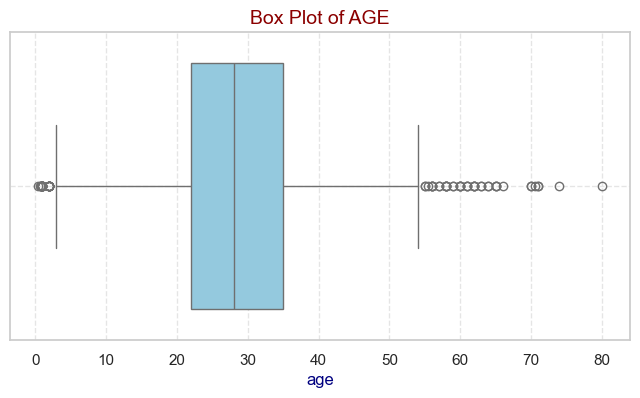

Insight: The box plot of age shows spread, median, and outliers.



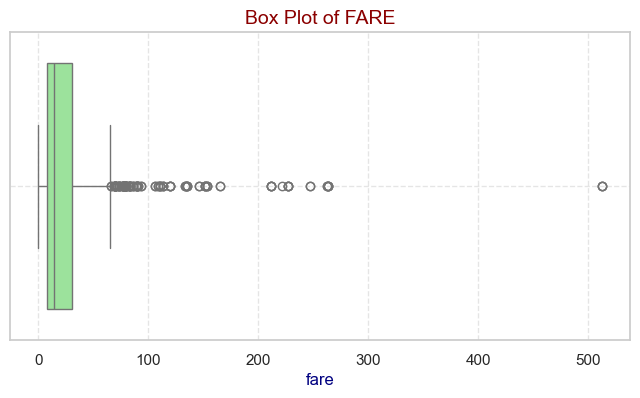

Insight: The box plot of fare shows spread, median, and outliers.



In [65]:
numeric_cols = ['age', 'fare']

colors = ['skyblue', 'lightgreen']

for col, color in zip(numeric_cols, colors):
    
    plt.figure(figsize=(8,4))
    
    sns.boxplot(
        x=df[col],
        color=color
    )
    
    plt.title(
        f"Box Plot of {col.upper()}",
        fontsize=14,
        color='darkred'
    )
    
    plt.xlabel(
        col,
        fontsize=12,
        color='navy'
    )
    
    plt.grid(True, linestyle='--', alpha=0.5)
    
    plt.show()
    
    print(f"Insight: The box plot of {col} shows spread, median, and outliers.\n")

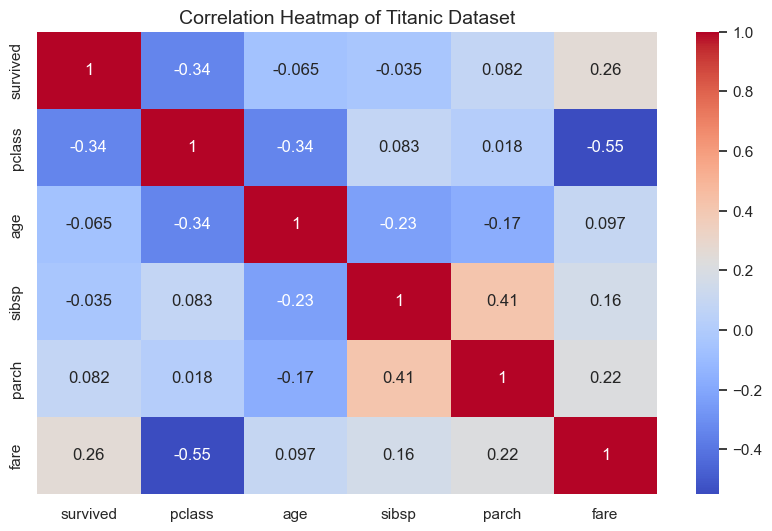

Insight: Passenger class and fare show a strong negative correlation, indicating higher classes paid higher fares.


<Figure size 640x480 with 0 Axes>

In [66]:
# heat map
# Select numeric columns
numeric_df = df.select_dtypes(include=np.number)

# Correlation matrix
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10,6))

sns.heatmap( corr_matrix, annot=True, cmap='coolwarm' )

plt.title("Correlation Heatmap of Titanic Dataset", fontsize=14)

plt.show()

plt.savefig('charts/heatmap.png')
 
print("Insight: Passenger class and fare show a strong negative correlation, indicating higher classes paid higher fares.")

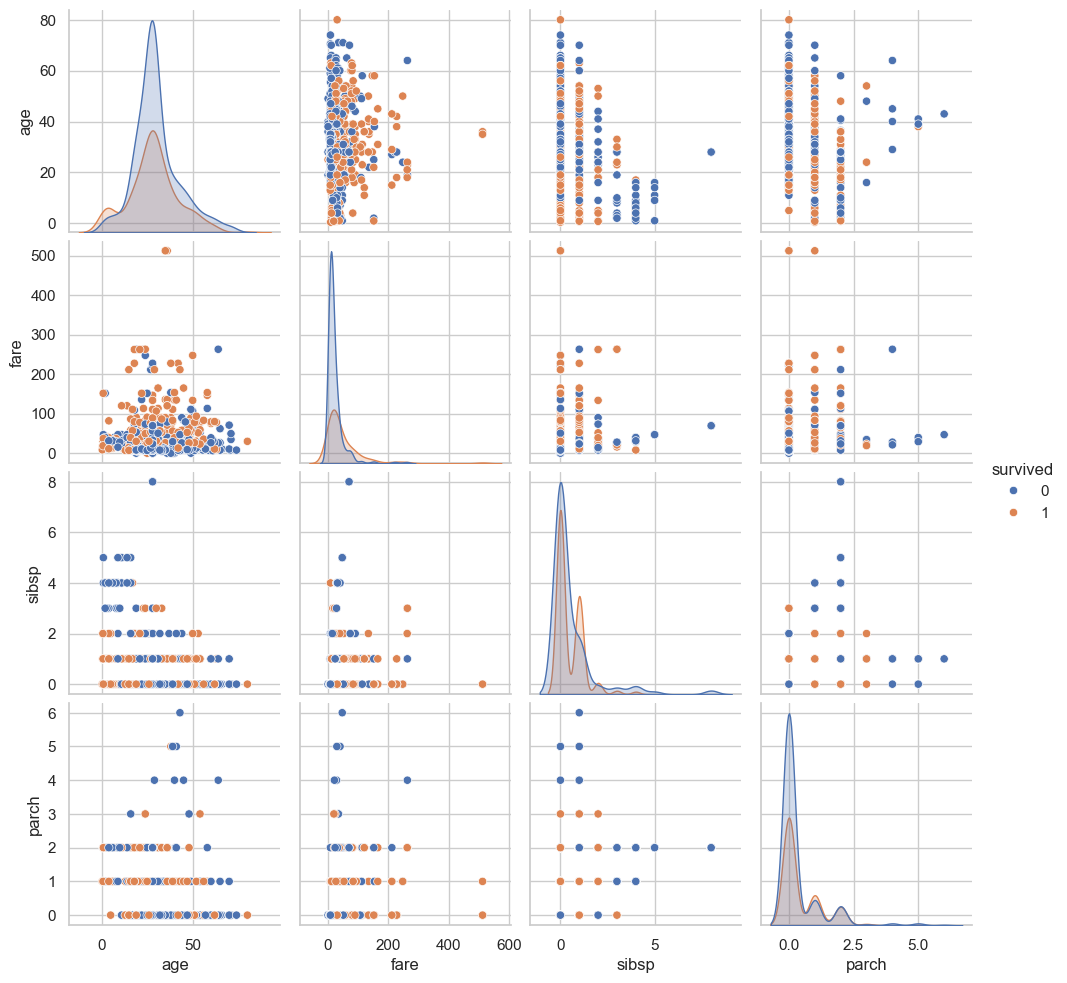

Insight: Pair plot helps visualize relationships, distributions, and survival patterns across all important numerical features.


<Figure size 640x480 with 0 Axes>

In [67]:
pairplot_df = df[['age', 'fare', 'sibsp', 'parch', 'survived']]

sns.pairplot(
    pairplot_df,
    hue='survived'
)

plt.show()

plt.savefig('charts/pairplot.png')

print("Insight: Pair plot helps visualize relationships, distributions, and survival patterns across all important numerical features.")

In [68]:
print(""" Summary:
      1. Female passengers had better survival rates.
      2. Higher passenger classes paid higher fares.
      3. Most passengers were young adults.
      4. Fare distribution contains several outliers.
      5. Passenger class strongly influenced fare prices.
      """)

 Summary:
      1. Female passengers had better survival rates.
      2. Higher passenger classes paid higher fares.
      3. Most passengers were young adults.
      4. Fare distribution contains several outliers.
      5. Passenger class strongly influenced fare prices.
      
